<a href="https://colab.research.google.com/github/Asigen93/Measurement-Report-Skripsi/blob/main/Per-Parameter-15_Hari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

raw = pd.read_excel(filename, header=None)

Saving Buat measurement Report.xlsx to Buat measurement Report.xlsx


In [3]:
import re

clean_rows = []
current_day = None

for _, row in raw.iterrows():

    first_cell = str(row[0]).strip() if pd.notna(row[0]) else ''

    day_match = re.match(r'Hari\s*(\d+)', first_cell, re.IGNORECASE)

    if day_match:
        current_day = int(day_match.group(1))
        continue

    if pd.isna(row[2]) or str(row[2]).strip() in ['Skenario (Lock)', '(20 mb)']:
        continue

    clean_rows.append({
        'Hari': current_day,
        'Skenario (Lock)': row[2],
        'RSRP (dBm)': row[6],
        'RSRQ (dB)': row[7],
        'SNR (dB)': row[8],
        'Throughput DL (Mbps)': row[11],
        'Throughput UL (Mbps)': row[12]
    })

df = pd.DataFrame(clean_rows)

print(df.head())

   Hari      Skenario (Lock)  RSRP (dBm)  RSRQ (dB)  SNR (dB)  \
0     1   EARFCN 500 PCI 261         -91        -14       4.8   
1     1  EARFCN 1850 PCI 261         -93        -13      20.0   
2     1  EARFCN 3500 PCI 261         -79        -11       8.2   
3     1   EARFCN 500 PCI 214         -88        -10      30.0   
4     1  EARFCN 3500 PCI 214         -77        -10      -4.0   

   Throughput DL (Mbps)  Throughput UL (Mbps)  
0                  10.0                   5.0  
1                   8.4                   6.7  
2                   2.8                   5.9  
3                  11.4                   6.2  
4                   2.8                   5.3  


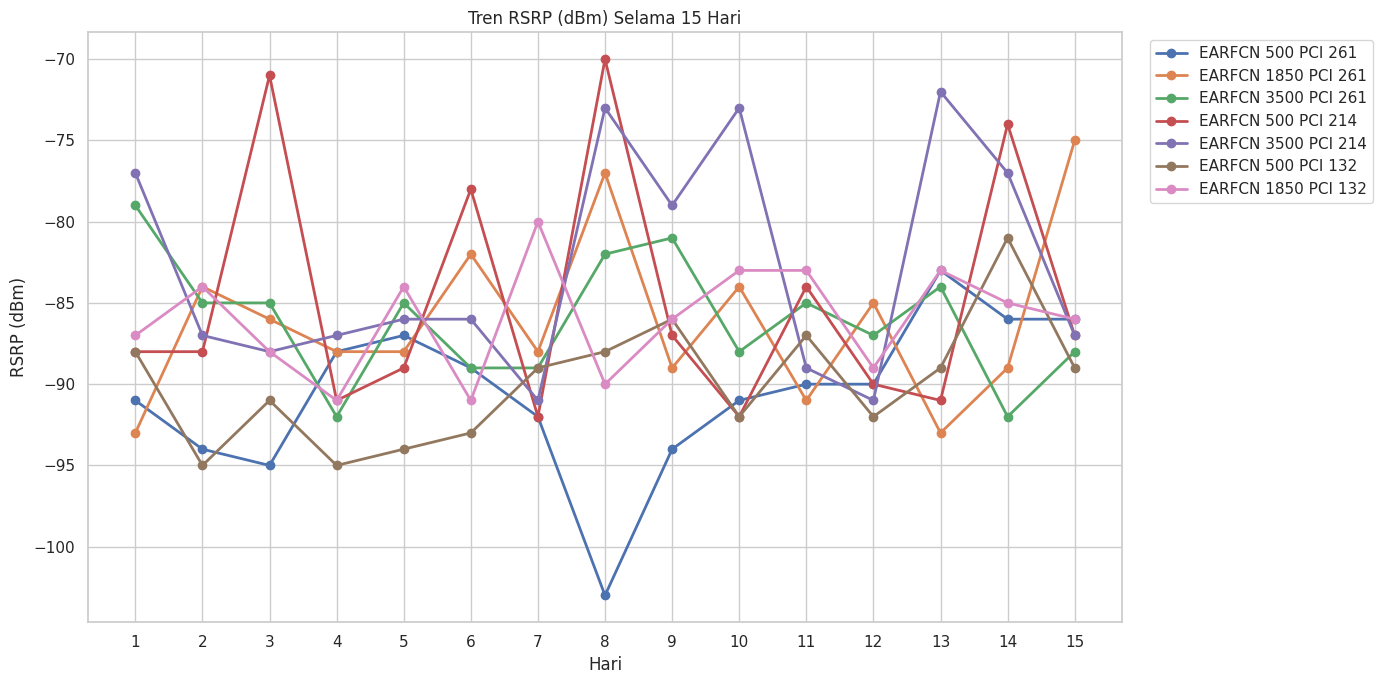

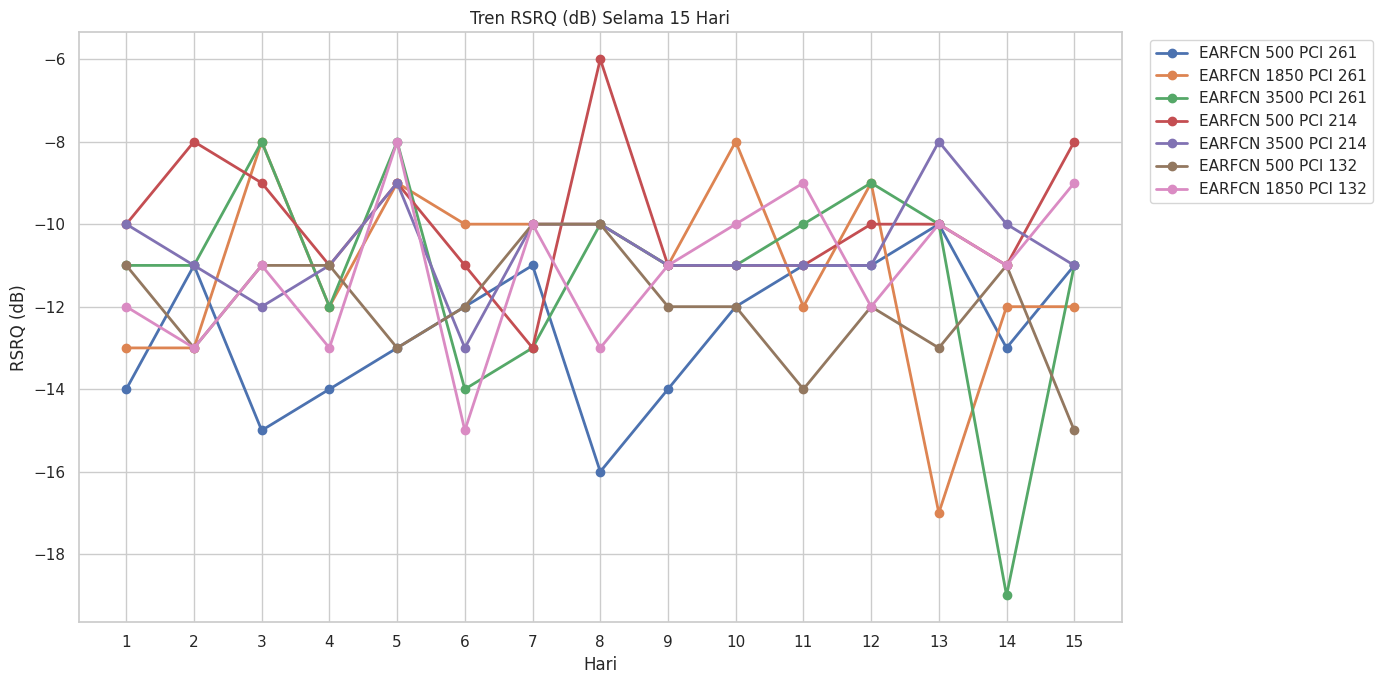

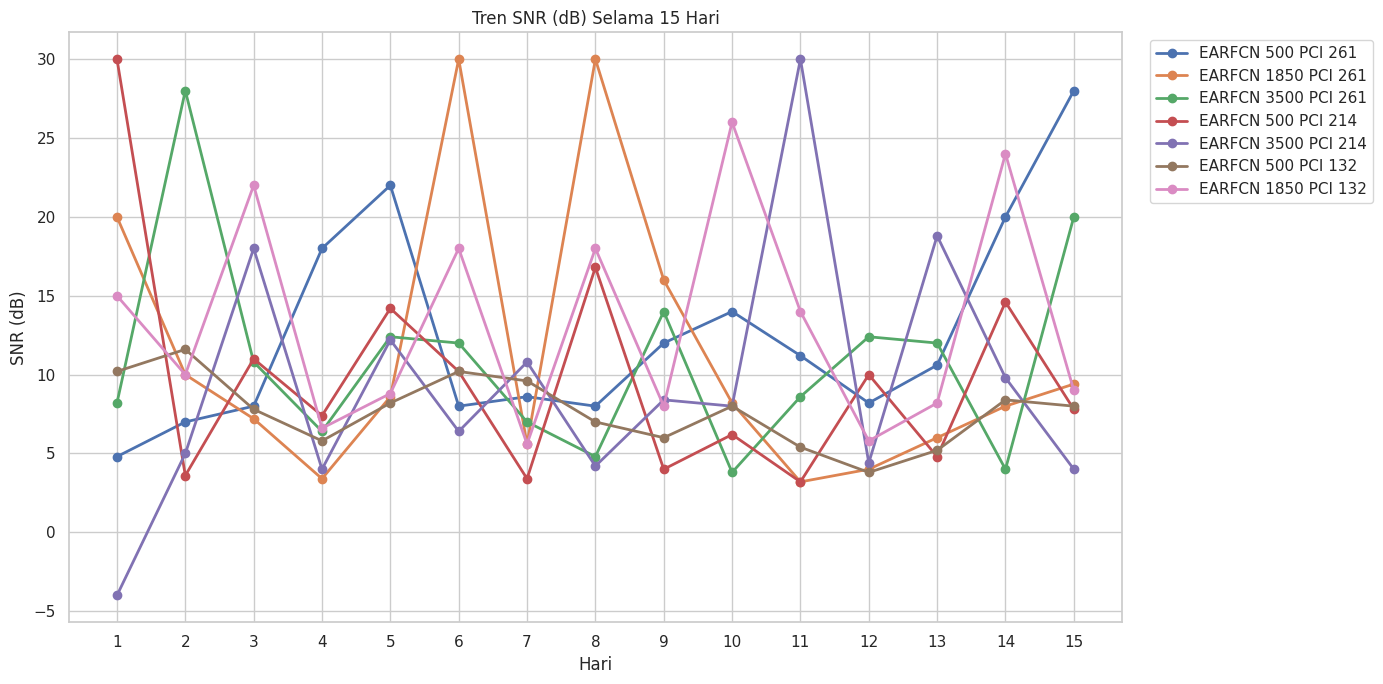

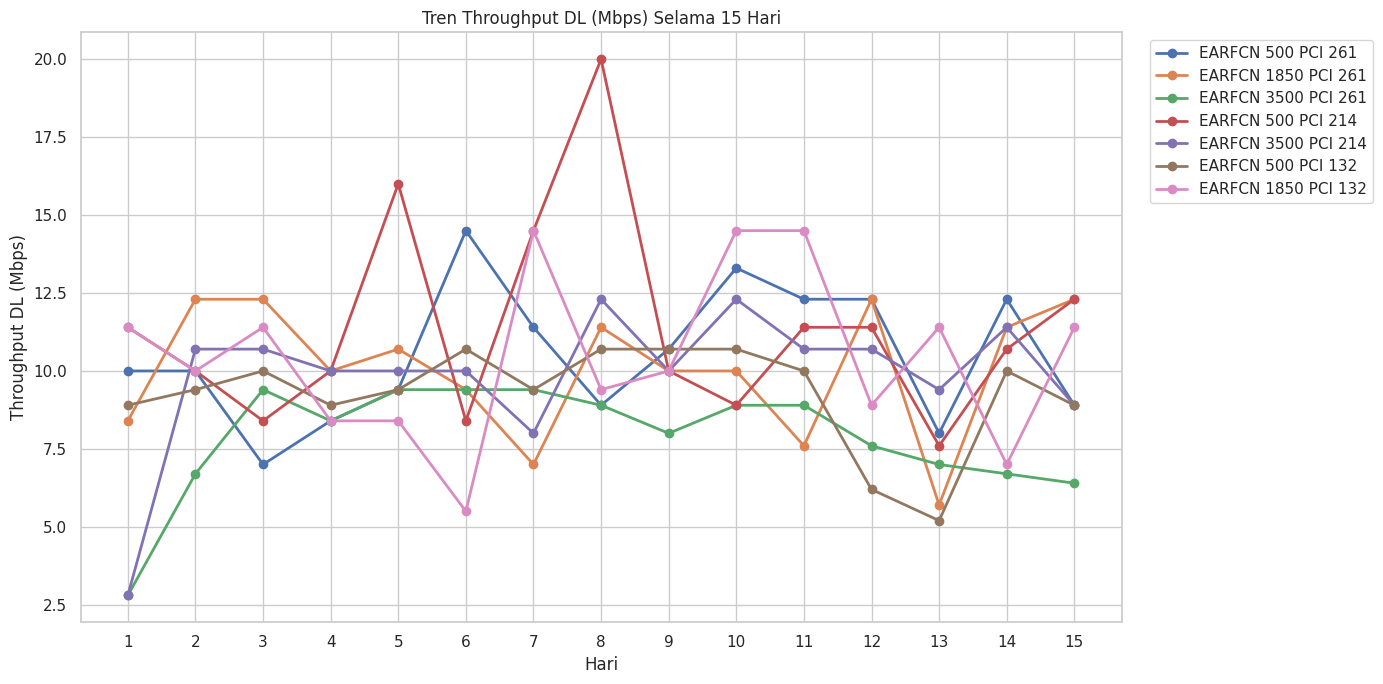

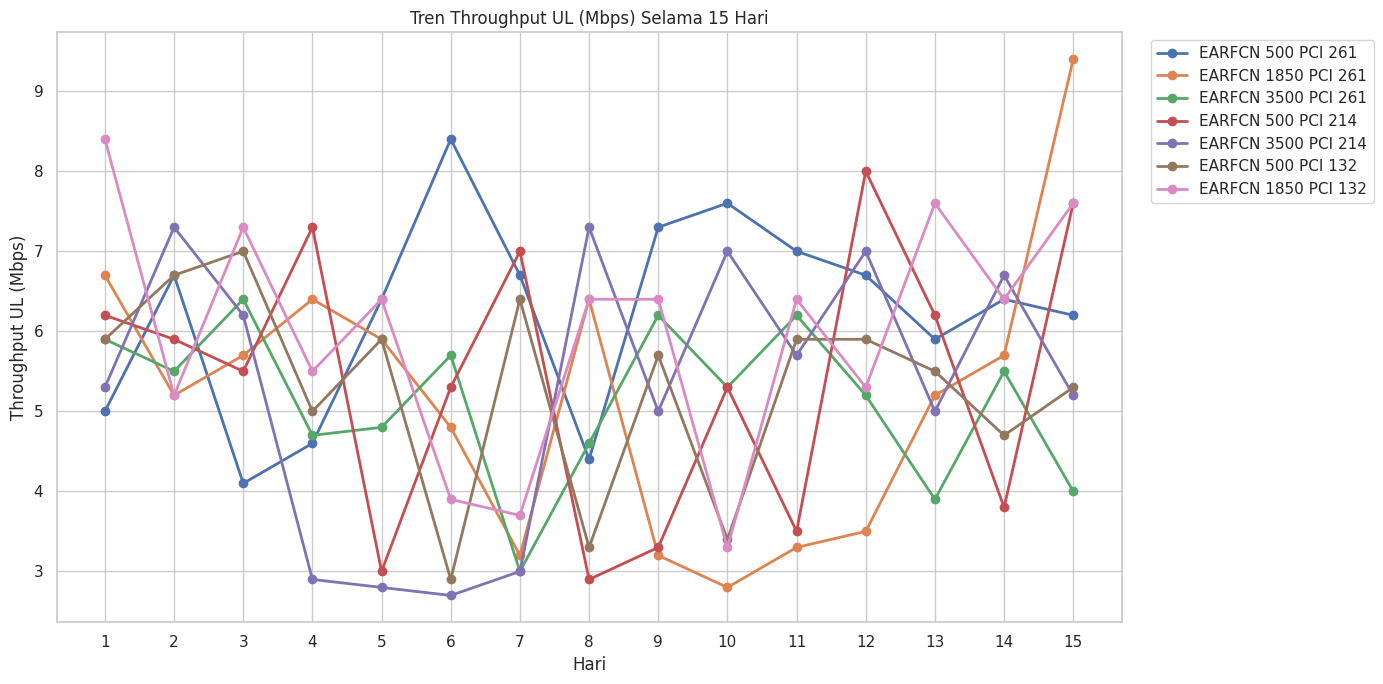

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

numeric_cols = [
    'RSRP (dBm)',
    'RSRQ (dB)',
    'SNR (dB)',
    'Throughput DL (Mbps)',
    'Throughput UL (Mbps)'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '.'),
        errors='coerce'
    )

for param in numeric_cols:

    plt.figure(figsize=(14,7))

    for skenario in df['Skenario (Lock)'].unique():

        temp = df[df['Skenario (Lock)'] == skenario].sort_values('Hari')

        plt.plot(
            temp['Hari'],
            temp[param],
            marker='o',
            linewidth=2,
            label=skenario
        )

    plt.title(f'Tren {param} Selama 15 Hari')
    plt.xlabel('Hari')
    plt.ylabel(param)
    plt.xticks(range(1,16))
    plt.grid(True)

    plt.legend(
        bbox_to_anchor=(1.02,1),
        loc='upper left'
    )

    plt.tight_layout()
    plt.show()